MODEL PERFORMANCE


,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.902379,0.968239,0.885622,0.925089
1,Random Forest,0.908327,0.973593,0.889434,0.929613
2,SVM,0.768280,0.773198,0.933317,0.845746


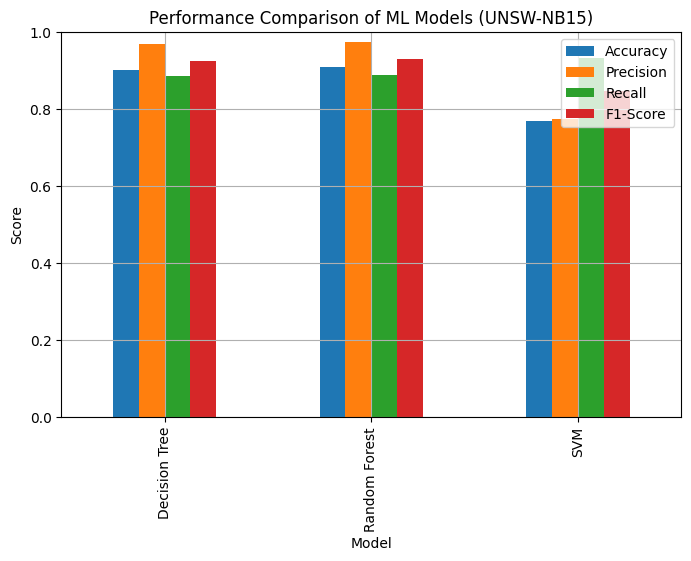

In [ ]:
# ===============================
# IMPORTS
# ===============================
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ===============================
# LOAD DATA
# ===============================
train_data = pd.read_csv("UNSW_NB15_training-set.csv")
test_data  = pd.read_csv("UNSW_NB15_testing-set.csv")

# ===============================
# FEATURE SELECTION
# ===============================
features = ['dur', 'proto', 'spkts', 'dpkts', 'sbytes', 'dbytes']
target = 'label'

# ===============================
# FIXED ENCODING
# ===============================
combined_proto = pd.concat([train_data['proto'], test_data['proto']])
le = LabelEncoder()
le.fit(combined_proto)

train_data['proto'] = le.transform(train_data['proto'])
test_data['proto']  = le.transform(test_data['proto'])

# ===============================
# CREATE X & y
# ===============================
X_train = train_data[features]
y_train = train_data[target]

X_test  = test_data[features]
y_test  = test_data[target]

# ===============================
# SCALING
# ===============================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# ===============================
# MODELS
# ===============================
from sklearn.svm import LinearSVC

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": LinearSVC(max_iter=5000)
}


# ===============================
# TRAIN & EVALUATE
# ===============================
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ])

results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"]
)

print("MODEL PERFORMANCE")
display(results_df)

# ===============================
# PLOT
# ===============================
results_df.set_index("Model").plot(kind="bar", figsize=(8,5))
plt.title("Performance Comparison of ML Models (UNSW-NB15)")
plt.ylabel("Score")
plt.ylim(0,1)
plt.grid()
plt.show()
